# Recurrent Neural Network (RNN) - IMDb Sentiment Analysis

Build and evaluate a vanilla Recurrent Neural Network for binary sentiment classification on the official TensorFlow IMDb dataset. This notebook establishes a baseline for later LSTM and GRU comparisons.


## 1. Import Required Libraries

Import the libraries required throughout the project.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.callbacks import EarlyStopping
print(tf.__version__)

2.21.0


## 2. Load the IMDb Dataset

Load the official TensorFlow IMDb dataset.

In [17]:
num_words=20000
maxlen=250
(X_train,y_train),(X_test,y_test)=imdb.load_data(num_words=num_words)
word_index=imdb.get_word_index()
reverse_word_index={v+3:k for k,v in word_index.items()}
reverse_word_index.update({0:'<PAD>',1:'<START>',2:'<UNK>',3:'<UNUSED>'})
print(len(X_train),len(X_test))

25000 25000


## 3. Explore the Dataset

Inspect the data distribution and sequence lengths.

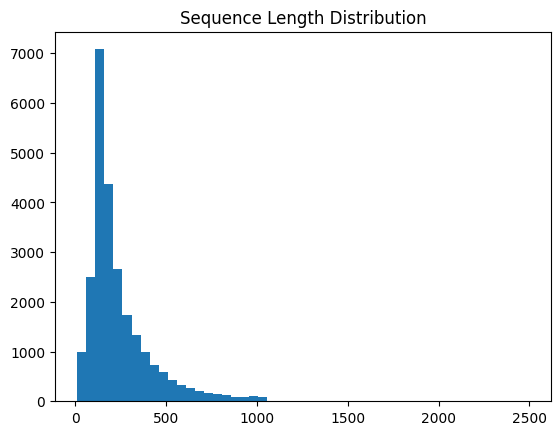

Positive: 12500 Negative: 12500


In [18]:
lengths=[len(x) for x in X_train]
plt.hist(lengths,bins=50)
plt.title('Sequence Length Distribution')
plt.show()
print('Positive:',np.sum(y_train),'Negative:',len(y_train)-np.sum(y_train))

## 4. Create Validation Set

Split training data into training and validation sets.

In [19]:
X_train,X_val,y_train,y_val=train_test_split(X_train,y_train,test_size=0.2,random_state=42,stratify=y_train)

## 5. Preprocess the Data

Pad sequences to a fixed length.

In [20]:
X_train=pad_sequences(X_train,maxlen=maxlen)
X_val=pad_sequences(X_val,maxlen=maxlen)
X_test=pad_sequences(X_test,maxlen=maxlen)

## 6. Build the Vanilla RNN Model

Construct a SimpleRNN-based sentiment classifier.

In [21]:
model = Sequential([
    Embedding(input_dim=num_words, output_dim=128),
    SimpleRNN(64),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

# Build the model
model.build(input_shape=(None, maxlen))

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 250, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,574,465 (9.82 MB)

 Trainable params: 2,574,465 (9.82 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Train the Model

Train with EarlyStopping.

In [22]:
history=model.fit(
    X_train,y_train,
    validation_data=(X_val,y_val),
    epochs=15,
    batch_size=64,
    callbacks=[EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)]
)

Epoch 1/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 74ms/step - accuracy: 0.6727 - loss: 0.5734 - val_accuracy: 0.8030 - val_loss: 0.4312
Epoch 2/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 84ms/step - accuracy: 0.8249 - loss: 0.3871 - val_accuracy: 0.6532 - val_loss: 0.5997
Epoch 3/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 84ms/step - accuracy: 0.8671 - loss: 0.3068 - val_accuracy: 0.8332 - val_loss: 0.4759
Epoch 4/15
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 84ms/step - accuracy: 0.9147 - loss: 0.2177 - val_accuracy: 0.7118 - val_loss: 0.6611


## 8. Training Curves

Visualize training history.

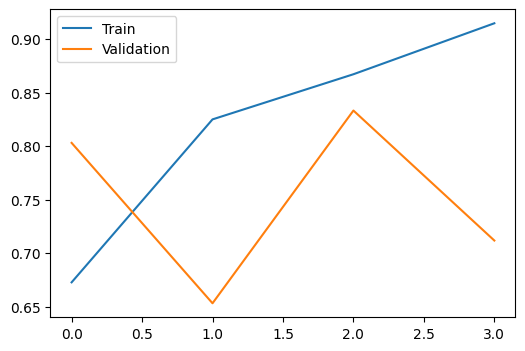

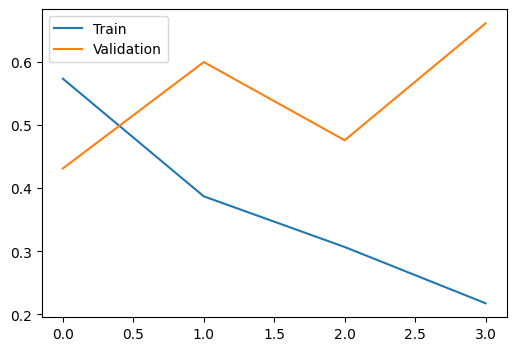

In [23]:
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'],label='Train')
plt.plot(history.history['val_accuracy'],label='Validation')
plt.legend(); plt.show()
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'],label='Train')
plt.plot(history.history['val_loss'],label='Validation')
plt.legend(); plt.show()

## 9. Evaluate on Test Data

Evaluate the model and generate predictions.

In [24]:
loss,acc=model.evaluate(X_test,y_test,verbose=0)
print(f'Test Accuracy: {acc:.4f}')
pred=(model.predict(X_test,verbose=0)>0.5).astype(int).ravel()

Test Accuracy: 0.8079


## 10. Classification Report

Compute precision, recall and F1-score.

In [25]:
print(classification_report(y_test,pred,digits=4))

              precision    recall  f1-score   support

           0     0.8276    0.7778    0.8019     12500
           1     0.7904    0.8379    0.8135     12500

    accuracy                         0.8079     25000
   macro avg     0.8090    0.8079    0.8077     25000
weighted avg     0.8090    0.8079    0.8077     25000



## 11. Confusion Matrix

Visualize classification performance.

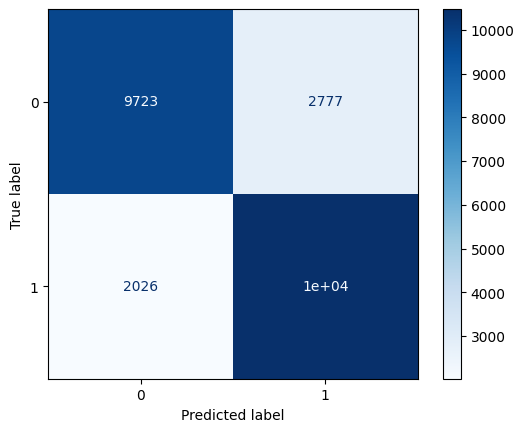

In [26]:
cm=confusion_matrix(y_test,pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.show()

## 12. Error Analysis

Review several misclassified examples.

In [27]:
mis=np.where(pred!=y_test)[0][:5]
for idx in mis:
    review=' '.join(reverse_word_index.get(i,'?') for i in X_test[idx] if i!=0)
    print('='*80)
    print('True:',y_test[idx],'Pred:',pred[idx])
    print(review[:1200],'...')

True: 0 Pred: 1
<START> i generally love this type of movie however this time i found myself wanting to kick the screen since i can't do that i will just complain about it this was absolutely idiotic the things that happen with the dead kids are very cool but the alive people are absolute idiots i am a grown man pretty big and i can defend myself well however i would not do half the stuff the little girl does in this movie also the mother in this movie is reckless with her children to the point of neglect i wish i wasn't so angry about her and her actions because i would have otherwise enjoyed the flick what a number she was take my advise and fast forward through everything you see her do until the end also is anyone else getting sick of watching movies that are filmed so dark anymore one can hardly see what is being filmed as an audience we are impossibly involved with the actions on the screen so then why the hell can't we have night vision ...
True: 1 Pred: 0
<START> i'm absolutely

# 13. Discussion

The SimpleRNN established a strong baseline for binary sentiment classification, achieving a test accuracy of **80.79%** while maintaining balanced performance across both sentiment classes. The learning curves indicate that the network rapidly learned meaningful sequential patterns during the initial training epochs, after which the training accuracy continued to increase while the validation performance plateaued. This behaviour is consistent with overfitting and suggests that the model began memorizing patterns specific to the training data rather than improving its ability to generalize.

The error analysis further highlights a known limitation of vanilla recurrent neural networks. Reviews containing lengthy narratives, multiple opinion shifts, or complex contextual dependencies were more likely to be misclassified. Since a SimpleRNN compresses all preceding information into a single hidden state, information from earlier portions of a sequence gradually becomes less influential as the sequence length increases. This limitation motivates the use of gated recurrent architectures such as LSTMs, which are specifically designed to preserve relevant information across longer sequences.

# 14. Key Findings

- The SimpleRNN achieved a **test accuracy of 80.79%**, demonstrating that recurrent neural networks can effectively model sequential text for sentiment classification.
- Precision and recall remained well balanced across both sentiment classes, indicating that the model did not exhibit a strong prediction bias toward either positive or negative reviews.
- Training accuracy continued to improve after validation performance had stabilized, providing evidence of overfitting despite the use of EarlyStopping.
- Misclassified reviews were predominantly longer reviews containing mixed or evolving sentiment, illustrating the difficulty of retaining long-range contextual information using a vanilla recurrent architecture.
- The results provide a meaningful baseline for subsequent LSTM and GRU implementations, where improvements can be directly attributed to enhanced memory mechanisms rather than changes in the dataset.

# 15. Conclusion

This project demonstrates that a vanilla Recurrent Neural Network is capable of learning meaningful sequential representations for natural language sentiment classification. Although the model achieved competitive performance, the observed overfitting and reduced performance on longer, context-rich reviews highlight the inherent limitations of traditional recurrent networks when modelling long-term dependencies.

These findings establish an appropriate baseline for the next stage of the repository, where Long Short-Term Memory (LSTM) networks will be introduced to evaluate how gated memory cells improve the retention of contextual information and overall model generalization.